# VAE

In [ ]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from mpl_toolkits.axes_grid1 import ImageGrid

In [3]:
# create a transofrm to apply to each datapoint
transform = transforms.Compose([transforms.ToTensor()])

# download the MNIST datasets
path = '~/datasets'
train_dataset = MNIST(path, transform=transform, download=True)
test_dataset  = MNIST(path, transform=transform, download=True)

# create train and test dataloaders
batch_size = 100
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

100.0%
100.0%
100.0%
100.0%


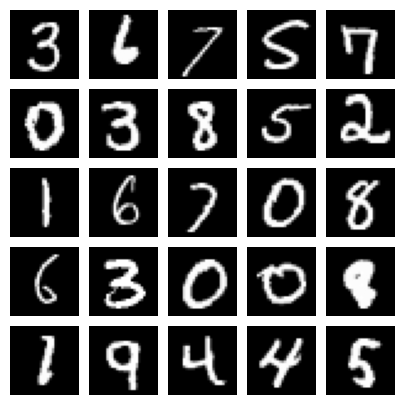

In [30]:
# get 25 sample training images for visualization
dataiter = iter(train_loader)
images, labels = next(dataiter)
num_samples = 25
sample_images = [images[i, 0] for i in range(num_samples)]

fig = plt.figure(figsize=(5, 5))
grid = ImageGrid(fig, 111, nrows_ncols=(5, 5), axes_pad=0.1)

for ax, im in zip(grid, sample_images):
    ax.imshow(im, cmap='gray')
    ax.axis('off')

plt.show()

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=2):

        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim

        # encoder: input -> hidden
        self.encoder_fc = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
        )
        # mean and logvar heads (each outputs latent_dim)
        self.mean_layer = nn.Linear(hidden_dim, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim, latent_dim)

        # decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(), 
        )

    def encode(self, x):

        h = self.encoder_fc(x)
        mean = self.mean_layer(h)
        logvar = self.logvar_layer(h)
        return mean, logvar

    def reparameterize(self, mean, logvar):

        # std from logvar:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)   # ensures same device/dtype
        z = mean + std * eps
        return z

    def decode(self, z):

        return self.decoder(z)

    def forward(self, x):

        mean, logvar = self.encode(x)
        z = self.reparameterize(mean, logvar)
        x_hat = self.decode(z)
        return x_hat, mean, logvar

In [ ]:
model = VAE(input_dim=784, hidden_dim=400, latent_dim=2).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [50]:
def loss_function(x, x_hat, mean, log_var):
    reproduction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    KLD = - 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp())

    return reproduction_loss + KLD

In [51]:
def train(model, optimizer, train_loader, loss_function, epochs, device):
    model.train()
    for epoch in range(epochs):
        overall_loss = 0
        for batch_idx, (x, _) in enumerate(train_loader):
            # Flatten the batch dynamically (no need for x_dim or batch_size)
            x = x.view(x.size(0), -1).to(device)

            optimizer.zero_grad()
            x_hat, mean, log_var = model(x)
            loss = loss_function(x, x_hat, mean, log_var)
            
            overall_loss += loss.item()
            
            loss.backward()
            optimizer.step()

        avg_loss = overall_loss / len(train_loader.dataset)
        print(f"Epoch {epoch+1} \t Average Loss: {avg_loss:.4f}")

train(model, optimizer, train_loader, loss_function, epochs=50, device=device)

Epoch 1 	 Average Loss: 188.5536
Epoch 2 	 Average Loss: 169.1341
Epoch 3 	 Average Loss: 165.3136
Epoch 4 	 Average Loss: 163.1648
Epoch 5 	 Average Loss: 161.7414
Epoch 6 	 Average Loss: 160.4892
Epoch 7 	 Average Loss: 159.4709
Epoch 8 	 Average Loss: 158.7030
Epoch 9 	 Average Loss: 157.8130
Epoch 10 	 Average Loss: 157.2016
Epoch 11 	 Average Loss: 156.5447
Epoch 12 	 Average Loss: 156.0560
Epoch 13 	 Average Loss: 155.5435
Epoch 14 	 Average Loss: 155.0526
Epoch 15 	 Average Loss: 154.7748
Epoch 16 	 Average Loss: 154.3767
Epoch 17 	 Average Loss: 154.1277
Epoch 18 	 Average Loss: 153.7154
Epoch 19 	 Average Loss: 153.5169
Epoch 20 	 Average Loss: 153.2457
Epoch 21 	 Average Loss: 153.0552
Epoch 22 	 Average Loss: 152.8044
Epoch 23 	 Average Loss: 152.5870
Epoch 24 	 Average Loss: 152.3599
Epoch 25 	 Average Loss: 152.2159
Epoch 26 	 Average Loss: 152.1126
Epoch 27 	 Average Loss: 151.7517
Epoch 28 	 Average Loss: 151.6722
Epoch 29 	 Average Loss: 151.5407
Epoch 30 	 Average Loss

In [ ]:
def evaluate_vae(model, data_loader, loss_function, device):
    model.eval()  # set model to evaluation mode
    total_loss = 0
    recon_loss_total = 0
    kl_loss_total = 0

    with torch.no_grad():
        for x, _ in data_loader:
            # Flatten input and move to the selected device
            x = x.view(x.size(0), -1).to(device)

            # Forward pass through the VAE
            x_hat, mean, log_var = model(x)

            # Compute reconstruction loss (BCE) and KL divergence
            recon_loss = F.binary_cross_entropy(x_hat, x, reduction='sum')
            kl_loss = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())

            # Total loss per batch
            loss = recon_loss + kl_loss

            total_loss += loss.item()
            recon_loss_total += recon_loss.item()
            kl_loss_total += kl_loss.item()

    # Average losses per sample
    num_samples = len(data_loader.dataset)
    avg_total_loss = total_loss / num_samples
    avg_recon_loss = recon_loss_total / num_samples
    avg_kl_loss = kl_loss_total / num_samples

    print(f"Validation Results:")
    print(f"  Average Total Loss: {avg_total_loss:.4f}")
    print(f"  Average Reconstruction Loss: {avg_recon_loss:.4f}")
    print(f"  Average KL Divergence: {avg_kl_loss:.4f}")

    return avg_total_loss, avg_recon_loss, avg_kl_loss


evaluate_vae(model, test_loader, loss_function, device)

Validation Results:
  Average Total Loss: 148.5260
  Average Reconstruction Loss: 142.3252
  Average KL Divergence: 6.2008


(148.52598880208333, 142.32521720377605, 6.200771636962891)

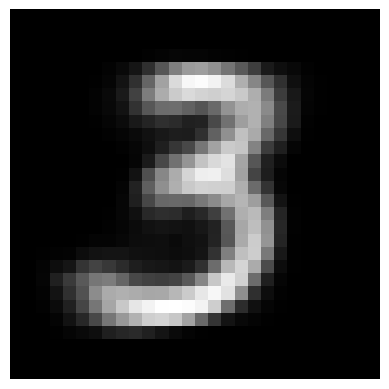

In [85]:
def generate_digit(z1=0.0, z2=0.0):
    model.eval()
    with torch.no_grad():
        latent_dim = 2
        z_sample = torch.zeros((1, latent_dim), dtype=torch.float).to(device)
        z_sample[0, 0] = z1   # vary first latent coordinate
        z_sample[0, 1] = z2   # vary second latent coordinate

        # decode to image
        x_decoded = model.decode(z_sample)
        digit = x_decoded.detach().cpu().view(28, 28)

    plt.imshow(digit, cmap='gray')
    plt.axis('off')
    plt.show()

generate_digit(1.0, -1.0)

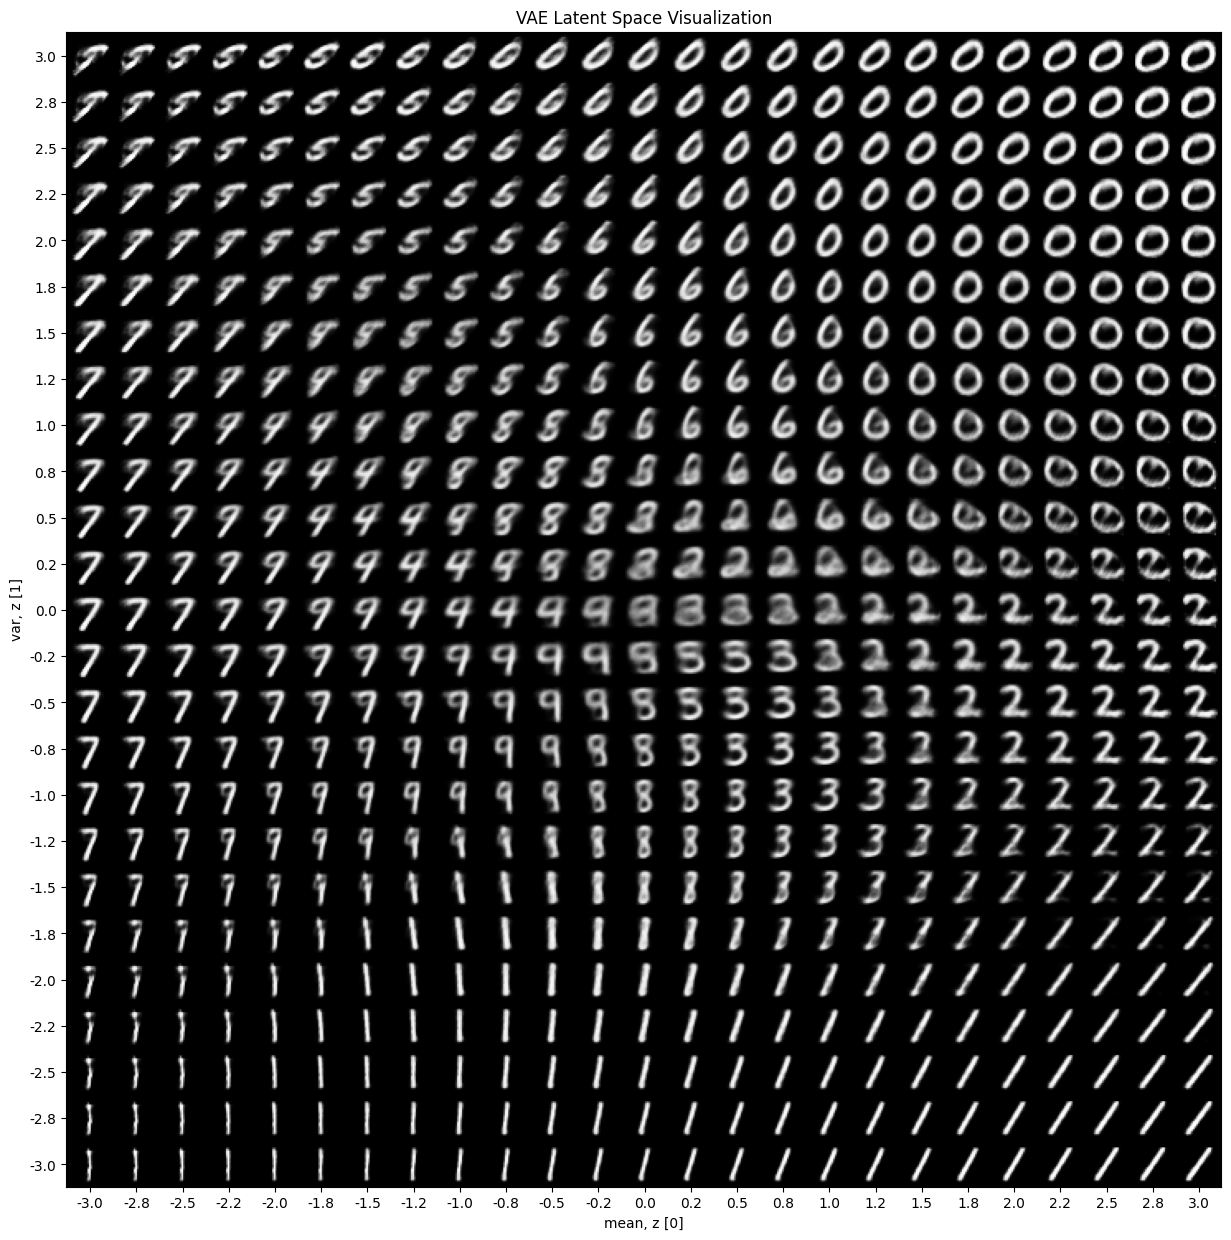

In [66]:
def plot_latent_space(model, scale=1.0, n=25, digit_size=28, figsize=15):
    # display a n*n 2D manifold of digits
    figure = np.zeros((digit_size * n, digit_size * n))

    # construct a grid 
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float).to(device)
            x_decoded = model.decode(z_sample)
            digit = x_decoded[0].detach().cpu().reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size,] = digit

    plt.figure(figsize=(figsize, figsize))
    plt.title('VAE Latent Space Visualization')
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("mean, z [0]")
    plt.ylabel("var, z [1]")
    plt.imshow(figure, cmap="Greys_r")
    plt.show()


plot_latent_space(model, scale=3.0, n=25, digit_size=28, figsize=15)